**Import packages and dependecies**

In [ ]:
%pip install -q -e ..

In [15]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from tda.rips import VietorisRips
from tda.plotting import plot_barcode, plot_persistence_diagram

**Calculating Vietoris Rips Simplex:**

In [2]:
np.random.seed(42)

n = 5 # Number of records or rows
m = 5 # Number of dimensions or columns
X = np.random.randint(1, 100, size=(n, m)) # Generate a sample dataset

# Find all Rips simplices
n_dimensions = 2
rips_config = VietorisRips(max_dim=n_dimensions,)
rips_result = rips_config.fit_transform(X, is_distance_matrix=False)

rips_by_dimension = {}
for i in range(n_dimensions+1):

    print(f"\n{i}-dimensional simplices (simplex_tuple, birth_time)")
    print("-"*100)

    result = [j for j in rips_result if len(j[0]) == i+1]
    for j in result:
        print(j)
    
    rips_by_dimension[i] = result


0-dimensional simplices (simplex_tuple, birth_time)
----------------------------------------------------------------------------------------------------
((0,), 0.0)
((1,), 0.0)
((2,), 0.0)
((3,), 0.0)
((4,), 0.0)

1-dimensional simplices (simplex_tuple, birth_time)
----------------------------------------------------------------------------------------------------
((2, 4), 53.34791467339656)
((0, 4), 54.909015653169384)
((0, 1), 80.31189202104505)
((0, 3), 85.94765849050223)
((1, 4), 92.19002115196633)
((0, 2), 93.62157870918435)
((3, 4), 101.04454463255303)
((1, 3), 101.65136496870073)
((2, 3), 122.79250791477467)
((1, 2), 135.34770038681853)

2-dimensional simplices (simplex_tuple, birth_time)
----------------------------------------------------------------------------------------------------
((0, 1, 4), 92.19002115196633)
((0, 2, 4), 93.62157870918435)
((0, 3, 4), 101.04454463255303)
((0, 1, 3), 101.65136496870073)
((1, 3, 4), 101.65136496870073)
((0, 2, 3), 122.79250791477467)
((2

**Persistence Barcode Plot of Rips Simplices**

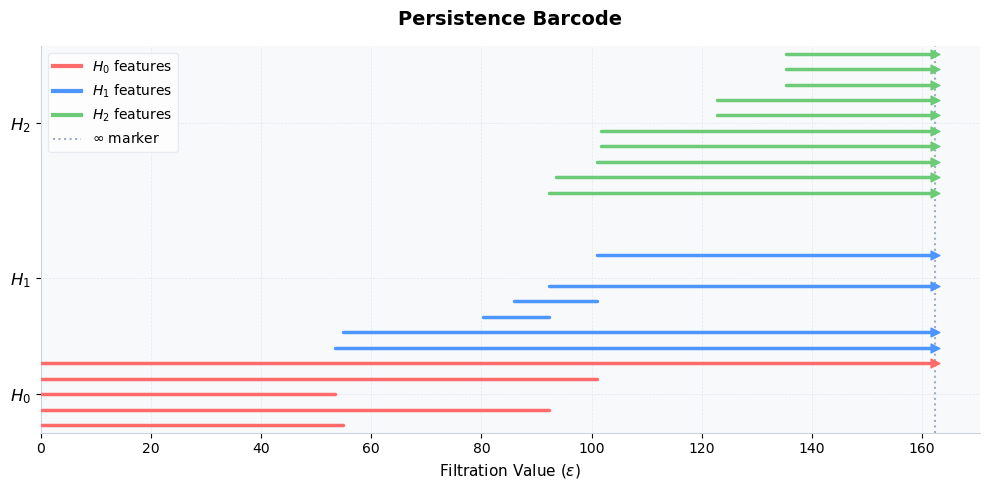

In [ ]:

# Initialize dictionary that will contain the (birth time, death time) for each simplex in the i-th dimension
birth_death_time_by_dimension = {}

for i, rips_results in rips_by_dimension.items():

    simplex_birth_death_time = []
    
    # Retrieve the simplex for the current i-th dimension
    i_simplex_list, i_birth_time_list = [k[0] for k in rips_results], [k[1] for k in rips_results]

    # Retrieve the simplex for the subsequent j-th dimension
    if i < n_dimensions:
        j_simplex_list, j_birth_time_list = [k[0] for k in rips_by_dimension[i+1]], [k[1] for k in rips_by_dimension[i+1]]

    # For each i simplex, determine if it forms a new j simplex in the subsequent dimension. If so, then the current i simplex has "died" in order to form the new j simplex.
    # Record the "death" of the i simplex as being the time when the new j simplex is formed.
    for i_simplex, i_birth_time in zip(i_simplex_list, i_birth_time_list):
        min_death_time = np.inf
        for j_simplex, j_birth_time in zip(j_simplex_list, j_birth_time_list):
            if i_simplex == j_simplex[:-1]:
                min_death_time = min(min_death_time, j_birth_time)
        
        simplex_birth_death_time.append((i_birth_time, min_death_time))
    
    birth_death_time_by_dimension[i] = simplex_birth_death_time

# Plot a persistence barcode plot showcasing the birth and death time of each simplex in each dimension
fig, ax = plt.subplots(figsize=(10, 5)) 
plot_barcode(intervals=birth_death_time_by_dimension, max_limit=None, ax=ax, show=False)
plt.show()


**Persistence Diagram of Rips Simplices**

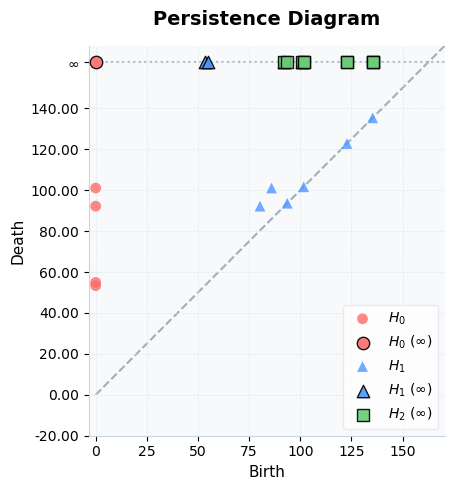

In [25]:
fig, ax = plt.subplots(figsize=(5,5)) 
plot_persistence_diagram(intervals=birth_death_time_by_dimension, max_limit=None, ax=ax, show=False)
plt.show()